<a href="https://colab.research.google.com/github/amathe1/GenAI-AgenticAI-Hub/blob/main/Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

How to calculate the number of parameters

In [ ]:
!pip install torch

In [ ]:
import torch
import torch.nn as nn

In [ ]:
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(3, 5)   # input layer
        self.fc2 = nn.Linear(5, 2)   # output layer

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        return x


In [ ]:
model = SimpleNet()

total_params = sum(p.numel() for p in model.parameters())
print("Total parameters:", total_params)


Total parameters: 32


In [ ]:
for name, param in model.named_parameters():
    print(name, param.shape, param.numel())


fc1.weight torch.Size([5, 3]) 15
fc1.bias torch.Size([5]) 5
fc2.weight torch.Size([2, 5]) 10
fc2.bias torch.Size([2]) 2


Regression Problem (House Price Prediction)

🎯 Problem

Predict house price based on:

Size (sqft)

Number of rooms

Step 1 — Import Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim


Step 2 — Create Dataset

In [ ]:
X = torch.tensor([
    [800,2],
    [1000,3],
    [1200,3],
    [1500,4],
    [1800,4]
], dtype=torch.float32)

y = torch.tensor([[200],[260],[300],[360],[420]], dtype=torch.float32)


In [ ]:
X

tensor([[ 800.,    2.],
        [1000.,    3.],
        [1200.,    3.],
        [1500.,    4.],
        [1800.,    4.]])

In [ ]:
y

tensor([[200.],
        [260.],
        [300.],
        [360.],
        [420.]])

Normalize inputs (important for neural nets):

In [ ]:
X = X / X.max(dim=0).values
y = y / y.max()


In [ ]:
X

tensor([[0.4444, 0.5000],
        [0.5556, 0.7500],
        [0.6667, 0.7500],
        [0.8333, 1.0000],
        [1.0000, 1.0000]])

In [ ]:
y

tensor([[0.4762],
        [0.6190],
        [0.7143],
        [0.8571],
        [1.0000]])

Step 3 — Define Model

In [ ]:
model = nn.Sequential(
    nn.Linear(2,8),
    nn.ReLU(),
    nn.Linear(8,1)
)


Step 4 — Loss & Optimizer

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)


Step 5 — Training Loop

In [ ]:
for epoch in range(500):
    pred = model(X)
    loss = criterion(pred,y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss {loss.item():.4f}")


Epoch 0, Loss 0.1714
Epoch 50, Loss 0.0014
Epoch 100, Loss 0.0006
Epoch 150, Loss 0.0004
Epoch 200, Loss 0.0003
Epoch 250, Loss 0.0003
Epoch 300, Loss 0.0003
Epoch 350, Loss 0.0002
Epoch 400, Loss 0.0002
Epoch 450, Loss 0.0002


Step 6 — Test Prediction

In [ ]:
test = torch.tensor([[1600,4]], dtype=torch.float32)
test = test / X.max(dim=0).values

print("Predicted price:", model(test)*420)


Predicted price: tensor([[430858.4375]], grad_fn=<MulBackward0>)


Classification Problem (Pass/Fail Prediction)

🎯 Problem

Predict if a student Passes (1) or Fails (0) based on:

Hours studied

Attendance %

Step 1 — Dataset

In [ ]:
X = torch.tensor([
    [1,40],
    [2,50],
    [3,60],
    [4,65],
    [5,75],
    [6,85]
], dtype=torch.float32)

y = torch.tensor([[0],[0],[0],[1],[1],[1]], dtype=torch.float32)

X = X / X.max(dim=0).values


Step 2 — Model

In [ ]:
model = nn.Sequential(
    nn.Linear(2,8),
    nn.ReLU(),
    nn.Linear(8,1),
    nn.Sigmoid()
)


Step 3 — Loss & Optimizer

In [ ]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)


Step 4 — Training

In [ ]:
for epoch in range(500):
    pred = model(X)
    loss = criterion(pred,y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss {loss.item():.4f}")


Epoch 0, Loss 0.7248
Epoch 50, Loss 0.6522
Epoch 100, Loss 0.4419
Epoch 150, Loss 0.2776
Epoch 200, Loss 0.2017
Epoch 250, Loss 0.1520
Epoch 300, Loss 0.1169
Epoch 350, Loss 0.0910
Epoch 400, Loss 0.0717
Epoch 450, Loss 0.0572


Step 5 — Test Prediction

In [ ]:
test = torch.tensor([[4,70]], dtype=torch.float32)
test = test / X.max(dim=0).values

prob = model(test)
print("Pass probability:", prob.item())
print("Prediction:", 1 if prob>0.5 else 0)


Pass probability: 1.0
Prediction: 1


Overfitting & How to prevent overfitting using Dropout,Early stopping and L2 Regularization

🌸 Iris Dataset (Real Dataset)

Task: Classify flower species into:

0 = Setosa

1 = Versicolor

2 = Virginica

Features:

Sepal length

Sepal width

Petal length

Petal width

Step 1 — Imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt


Step 2 — Load Dataset

In [ ]:
data = load_iris()
X = data.data
y = data.target


In [ ]:
data = load_iris()


In [ ]:
data

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

Step 3 — Train/Validation Split

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.4, random_state=42
)


In [ ]:
X.shape

(150, 4)

In [ ]:
y.shape

(150,)

In [ ]:
X_train.shape

(90, 4)

In [ ]:
X_val.shape

(60, 4)

In [ ]:
y_train.shape

(90,)

In [ ]:
y_val.shape

(60,)

Step 4 — Normalize

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
# type(X_train)
# type(X_val)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)


PART 1 — OVERFITTING MODEL

In [ ]:
class OverfitModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4,128),
            nn.ReLU(),
            nn.Linear(128,128),
            nn.ReLU(),
            nn.Linear(128,3)
        )

    def forward(self,x):
        return self.net(x)


Training Function

In [ ]:
def train_model(model, optimizer, epochs=200):
    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        pred = model(X_train)
        loss = criterion(pred, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

    return train_losses, val_losses


Train

In [ ]:
model1 = OverfitModel()
opt1 = optim.Adam(model1.parameters(), lr=0.01)

train1, val1 = train_model(model1, opt1)


📉 Visualize Overfitting

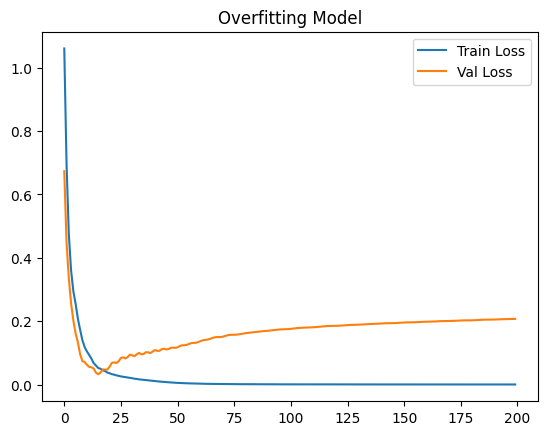

In [ ]:
plt.plot(train1,label="Train Loss")
plt.plot(val1,label="Val Loss")
plt.legend()
plt.title("Overfitting Model")
plt.show()


REGULARIZED MODEL

Apply:

✅ Dropout

✅ L2

✅ Early stopping

Regularized Model

In [ ]:
class RegularizedModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4,128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64,3)
        )

    def forward(self,x):
        return self.net(x)


Early Stopping Training

In [ ]:
def train_with_early_stopping(model, optimizer, patience=15):
    criterion = nn.CrossEntropyLoss()

    best_loss = float('inf')
    counter = 0

    train_losses, val_losses = [], []

    for epoch in range(300):
        model.train()
        pred = model(X_train)
        loss = criterion(pred,y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        model.eval()
        val_pred = model(X_val)
        val_loss = criterion(val_pred,y_val)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        if val_loss < best_loss:
            best_loss = val_loss
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            print("Early stopping triggered")
            break

    return train_losses,val_losses


Train Regularized

(L2 via weight_decay)

In [ ]:
model2 = RegularizedModel()
opt2 = optim.Adam(model2.parameters(), lr=0.01, weight_decay=1e-3)

train2, val2 = train_with_early_stopping(model2, opt2)


Early stopping triggered


📊 Visualize After Fix

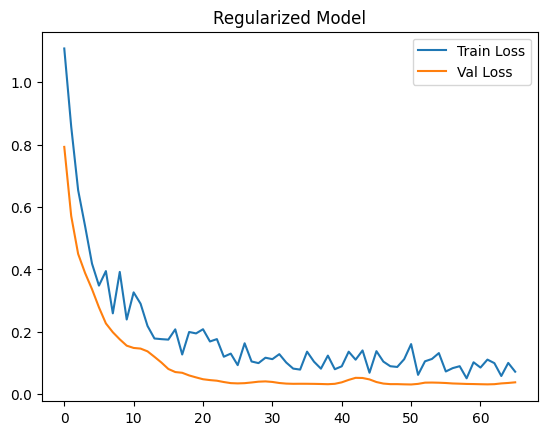

In [ ]:
plt.plot(train2,label="Train Loss")
plt.plot(val2,label="Val Loss")
plt.legend()
plt.title("Regularized Model")
plt.show()


Vanishing Gradient & Preventing Vanishing Gradient using Xavier weight initialization, Batch Normalization

🎯 Goal

We will:

Build a deep sigmoid network → vanishing gradients

Measure gradient magnitudes

Fix with:

Xavier initialization

BatchNorm

Compare gradient flow visually

Step 1 — Imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms


Step 2 — Load MNIST (Real Dataset)

In [ ]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(root="./data", train=True,
                             download=True, transform=transform)

loader = torch.utils.data.DataLoader(train_data,
                                     batch_size=128,
                                     shuffle=True)

images, labels = next(iter(loader)) #  (batch_size, channels, height, width)


In [ ]:
images.shape

torch.Size([128, 1, 28, 28])

In [ ]:
images = images.view(images.size(0), -1)  # Flatten

In [ ]:
images.shape

torch.Size([128, 784])

Vanishing Gradient Model

Deep network + sigmoid → classic vanishing gradient.

In [ ]:
class VanishingNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(784,256),
            nn.Sigmoid(),
            nn.Linear(256,256),
            nn.Sigmoid(),
            nn.Linear(256,256),
            nn.Sigmoid(),
            nn.Linear(256,10)
        )

    def forward(self,x):
        return self.layers(x)


Function to Capture Gradients

In [ ]:
def get_gradients(model, data, target):
    criterion = nn.CrossEntropyLoss()
    output = model(data)
    loss = criterion(output,target)
    loss.backward()

    grads = []
    for name, param in model.named_parameters():
        if "weight" in name:
            grads.append(param.grad.abs().mean().item())

    return grads


Train One Step & Collect Gradients

In [ ]:
model_bad = VanishingNet()
opt = optim.SGD(model_bad.parameters(), lr=0.1)

opt.zero_grad()
bad_grads = get_gradients(model_bad, images, labels)


📉 Visualize Vanishing Gradients

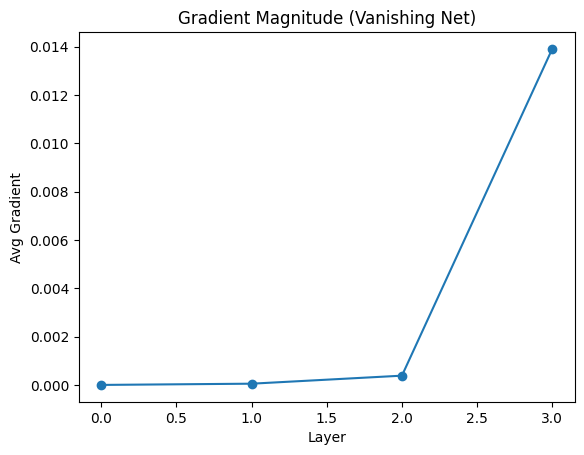

In [ ]:
plt.plot(bad_grads, marker='o')
plt.title("Gradient Magnitude (Vanishing Net)")
plt.xlabel("Layer")
plt.ylabel("Avg Gradient")
plt.show()


👉 You’ll see:

Early layers → extremely tiny gradients
= Vanishing gradient problem

Fix Vanishing Gradients

We apply:

✅ Xavier Initialization

✅ Batch Normalization

✅ ReLU activation

Improved Model

In [ ]:
class FixedNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784,256)
        self.bn1 = nn.BatchNorm1d(256)

        self.fc2 = nn.Linear(256,256)
        self.bn2 = nn.BatchNorm1d(256)

        self.fc3 = nn.Linear(256,256)
        self.bn3 = nn.BatchNorm1d(256)

        self.fc4 = nn.Linear(256,10)

        self.relu = nn.ReLU()

        self.init_weights()

    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)

    def forward(self,x):
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.relu(self.bn3(self.fc3(x)))
        x = self.fc4(x)
        return x


Measure Gradients Again

In [ ]:
model_good = FixedNet()
opt = optim.SGD(model_good.parameters(), lr=0.1)

opt.zero_grad()
good_grads = get_gradients(model_good, images, labels)


📊 Visualize Improved Gradient Flow

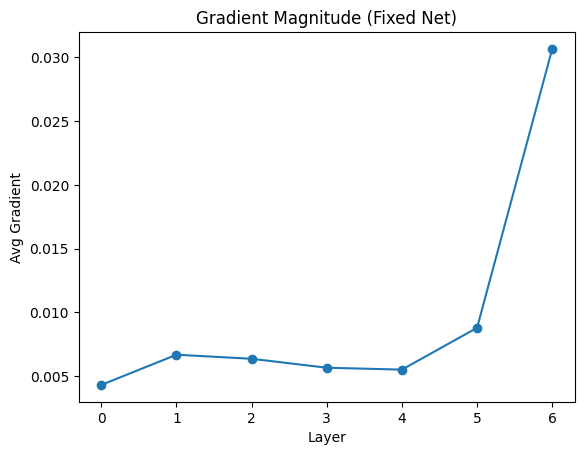

In [ ]:
plt.plot(good_grads, marker='o')
plt.title("Gradient Magnitude (Fixed Net)")
plt.xlabel("Layer")
plt.ylabel("Avg Gradient")
plt.show()


🧠 What You’ll Observe

BEFORE Fix

❌ Gradients shrink drastically

❌ Early layers almost zero

❌ Learning slows/stops

AFTER Fix

✅ Gradients stable across layers

✅ Faster learning

✅ Deep network trains properly

🎯 What is Underfitting?

Underfitting happens when:

Model is too simple

Cannot capture data patterns

High error on BOTH train & validation

👉 Like a student who studies too little and fails both practice and final exams.

Step 1 — Imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


Step 2 — Create Non-Linear Dataset

In [ ]:
torch.manual_seed(0)

X = torch.linspace(-3, 3, 100).view(-1,1)
y = torch.sin(X) + 0.1*torch.randn_like(X)


📊 Visualize Data

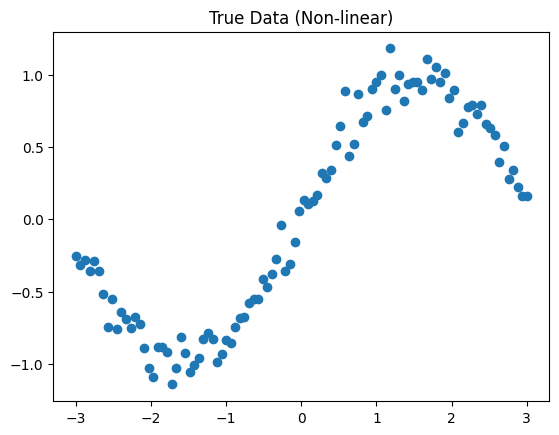

In [ ]:
plt.scatter(X.numpy(), y.numpy())
plt.title("True Data (Non-linear)")
plt.show()


UNDERFITTING MODEL

In [ ]:
model_underfit = nn.Linear(1,1)


Training

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.SGD(model_underfit.parameters(), lr=0.01)

losses_under = []

for epoch in range(200):
    pred = model_underfit(X)
    loss = criterion(pred,y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses_under.append(loss.item())


📉 Visualization (Underfitting)

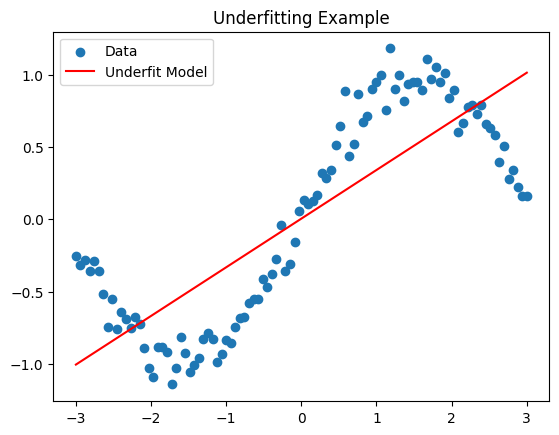

In [ ]:
with torch.no_grad():
    pred_under = model_underfit(X)

plt.scatter(X,y,label="Data")
plt.plot(X,pred_under,color='red',label="Underfit Model")
plt.legend()
plt.title("Underfitting Example")
plt.show()


👉 You’ll see:

❌ Straight line trying to fit curve
❌ Large errors
❌ Model too simple

= UNDERFITTING

Fix Underfitting

We improve by:

✅ Increasing model complexity

✅ More layers

✅ Non-linear activation

✅ More training

Better Model

In [ ]:
model_good = nn.Sequential(
    nn.Linear(1,32),
    nn.ReLU(),
    nn.Linear(32,32),
    nn.ReLU(),
    nn.Linear(32,1)
)


Training

In [ ]:
optimizer = optim.Adam(model_good.parameters(), lr=0.01)

losses_good = []

for epoch in range(1000):
    pred = model_good(X)
    loss = criterion(pred,y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses_good.append(loss.item())


📈 Visualization (After Fix

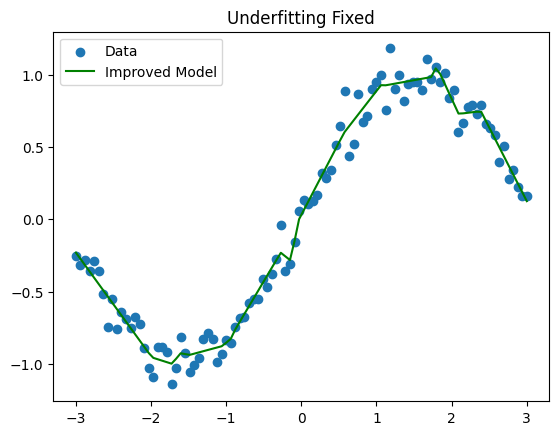

In [ ]:
with torch.no_grad():
    pred_good = model_good(X)

plt.scatter(X,y,label="Data")
plt.plot(X,pred_good,color='green',label="Improved Model")
plt.legend()
plt.title("Underfitting Fixed")
plt.show()


👉 Now you’ll see:

✅ Curve fits data

✅ Much lower error

✅ Model captures pattern

🧠 Prevention Techniques for Underfitting

✅ 1) Increase Model Capacity

More layers / neurons

👉 Small brain → can't learn

👉 Bigger brain → learns patterns

✅ 2) Add Non-Linear Activations

ReLU, Tanh, GELU

👉 Real-world data rarely linear

✅ 3) Train Longer

Sometimes model just needs more time.

✅ 4) Reduce Regularization

Too much dropout/L2 can cause underfitting.

✅ 5) Better Features

More informative inputs → better learning.

Exploading Gradients & Prevention Techniques

🎯 What Are Exploding Gradients?

Exploding gradients happen when:

Gradients become extremely large

Weight updates become huge

Training becomes unstable

Loss becomes NaN or wildly oscillates

👉 Like giving a student feedback with a megaphone so loud they panic and overreact.

✅ Apply fixes:

Gradient clipping

Proper initialization

Lower learning rate

Step 1 — Imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


Step 2 — Create Dummy Dataset

In [ ]:
torch.manual_seed(0)

X = torch.randn(512, 10)
y = torch.sum(X, dim=1, keepdim=True)  # simple regression target


Model That Explodes

We create:

Deep network

Poor initialization

High learning rate
= Perfect recipe for exploding gradients

Model

In [ ]:
class ExplodingNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(10,128),
            nn.ReLU(),
            nn.Linear(128,128),
            nn.ReLU(),
            nn.Linear(128,128),
            nn.ReLU(),
            nn.Linear(128,1)
        )

    def forward(self,x):
        return self.net(x)


Helper: Gradient Norm

In [ ]:
def grad_norm(model):
    total = 0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.norm().item()
    return total


Training (High LR = explosion)

In [ ]:
model_bad = ExplodingNet()
criterion = nn.MSELoss()

optimizer = optim.SGD(model_bad.parameters(), lr=1.0)  # VERY HIGH LR

bad_norms = []
bad_losses = []

for epoch in range(50):
    pred = model_bad(X)
    loss = criterion(pred,y)

    optimizer.zero_grad()
    loss.backward()

    bad_norms.append(grad_norm(model_bad))
    bad_losses.append(loss.item())

    optimizer.step()


📉 Visualize Exploding Gradients

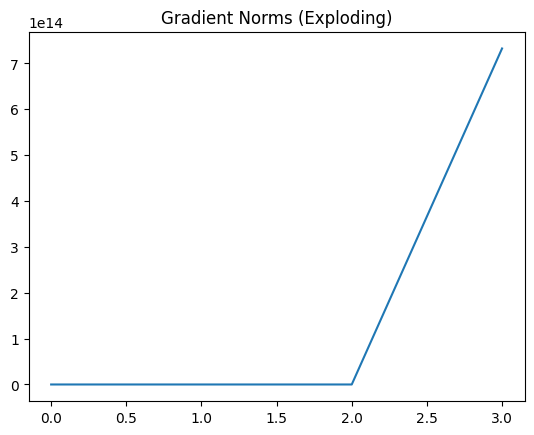

In [ ]:
plt.plot(bad_norms)
plt.title("Gradient Norms (Exploding)")
plt.show()


👉 You’ll often see:

Huge spikes

Possibly inf or NaN

📉 Loss Behavior

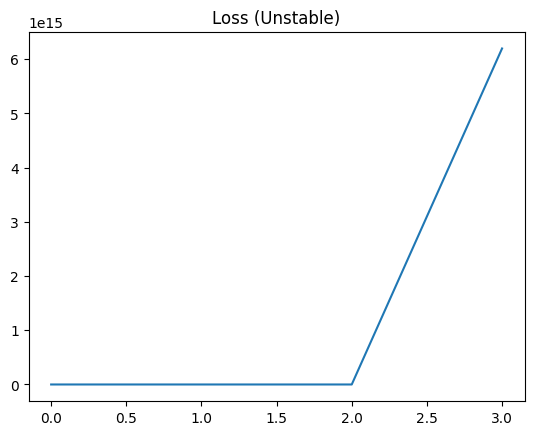

In [ ]:
plt.plot(bad_losses)
plt.title("Loss (Unstable)")
plt.show()


👉 Loss may:

Jump wildly

Become NaN

Not converge

Fix Exploding Gradients

We apply:

✅ Gradient clipping

✅ He initialization

✅ Lower learning rate

Improved Model

In [ ]:
class StableNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(10,128),
            nn.ReLU(),
            nn.Linear(128,128),
            nn.ReLU(),
            nn.Linear(128,128),
            nn.ReLU(),
            nn.Linear(128,1)
        )

        self.init_weights()

    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight)

    def forward(self,x):
        return self.layers(x)


Training with Fixes

In [ ]:
model_good = StableNet()
optimizer = optim.SGD(model_good.parameters(), lr=0.01)

good_norms = []
good_losses = []

for epoch in range(50):
    pred = model_good(X)
    loss = criterion(pred,y)

    optimizer.zero_grad()
    loss.backward()

    # Gradient clipping
    torch.nn.utils.clip_grad_norm_(model_good.parameters(), 1.0)

    good_norms.append(grad_norm(model_good))
    good_losses.append(loss.item())

    optimizer.step()


📊 Visualize Fixed Gradients

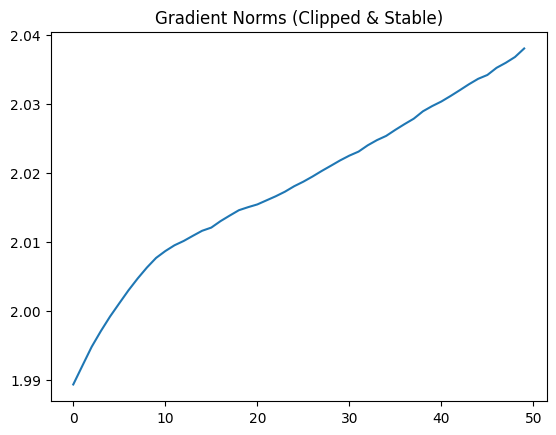

In [ ]:
plt.plot(good_norms)
plt.title("Gradient Norms (Clipped & Stable)")
plt.show()


👉 Now:

✅ Smooth
✅ Controlled
✅ No spikes

📊 Loss After Fix

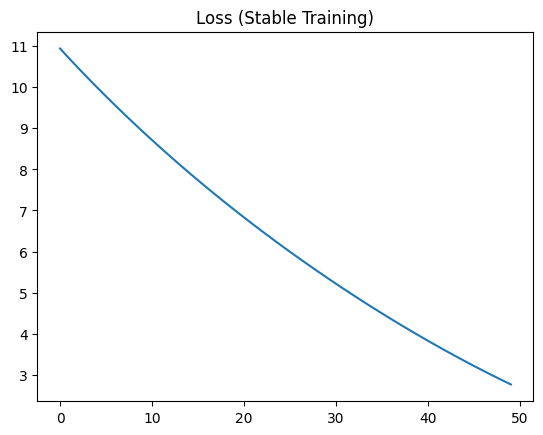

In [ ]:
plt.plot(good_losses)
plt.title("Loss (Stable Training)")
plt.show()


📌 Business Context

A telecom company wants to predict customer churn risk using customer usage, billing, and contract data.

The model must classify each customer into three risk categories:

Class	Meaning

0	Low churn risk

1	Medium churn risk

2	High churn risk

| monthly_charges | total_charges | tenure | services | calls | data_gb | contract_value | discount | churn |
| --------------- | ------------- | ------ | -------- | ----- | ------- | -------------- | -------- | ----- |
| 45              | 1200          | 6      | 2        | 8     | 15      | 12000          | 5        | 1     |
| 180             | 45000         | 60     | 5        | 1     | 300     | 80000          | 10       | 0     |
| 25              | 300           | 2      | 1        | 12    | 5       | 5000           | 0        | 2     |
| 90              | 15000         | 24     | 3        | 4     | 80      | 30000          | 15       | 1     |
| 200             | 50000         | 72     | 6        | 0     | 400     | 100000         | 20       | 0     |
| 30              | 600           | 4      | 1        | 20    | 8       | 8000           | 0        | 2     |
| 140             | 22000         | 36     | 4        | 3     | 150     | 50000          | 12       | 1     |
| 55              | 2000          | 10     | 2        | 6     | 30      | 15000          | 8        | 1     |
| 190             | 48000         | 68     | 6        | 0     | 380     | 90000          | 18       | 0     |
| 35              | 900           | 5      | 1        | 15    | 12      | 10000          | 2        | 2     |
